# Homework 2 — Machine Learning for Regression
**ML Zoomcamp 2026 · DataTalks.Club**

Goal: predict `fuel_efficiency_mpg` with linear regression, implemented from scratch with NumPy (lecture code).

Dataset: pinned 2026 Car Fuel Efficiency release (`car_fuel_efficiency_2026.csv`).

In [1]:
import hashlib
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load the data
Downloads the CSV once, then checks it is the exact pinned 2026 release (SHA-256 from `cohorts/2026/data/README.md`).

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/"
    "main/cohorts/2026/data/car_fuel_efficiency_2026.csv"
)
CSV_PATH = "car_fuel_efficiency_2026.csv"

if not os.path.exists(CSV_PATH):
    urllib.request.urlretrieve(DATA_URL, CSV_PATH)

EXPECTED_SHA256 = "00a5cab178a8b7cd6e9157ee71dabc236ba7f20b1832336d358b07af14ba431f"
with open(CSV_PATH, "rb") as f:
    sha256 = hashlib.sha256(f.read()).hexdigest()
print("Pinned 2026 release:", sha256 == EXPECTED_SHA256)

df_full = pd.read_csv(CSV_PATH)
df_full.shape

Pinned 2026 release: True


(10000, 11)

## Prepare the dataset
Keep only the 4 features + the target.

In [3]:
features = ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]
target = "fuel_efficiency_mpg"

df = df_full[features + [target]]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## EDA — does `fuel_efficiency_mpg` have a long tail?

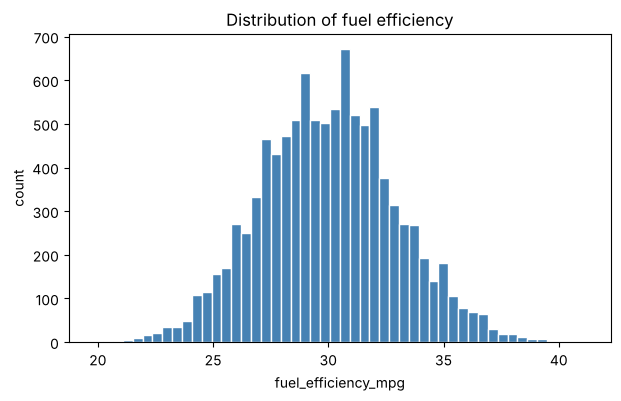

skewness: 0.081


count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

In [4]:
plt.figure(figsize=(7, 4))
plt.hist(df[target], bins=50, color="steelblue", edgecolor="white")
plt.xlabel("fuel_efficiency_mpg")
plt.ylabel("count")
plt.title("Distribution of fuel efficiency")
plt.show()

print("skewness:", round(df[target].skew(), 3))
df[target].describe()

**No long tail.** The distribution is roughly symmetric (skewness ≈ 0.08), so the target stays as-is — no log transform.

## Question 1 — which column has missing values?

In [5]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

**Answer Q1: `horsepower`** (877 missing values)

## Question 2 — median of `horsepower`

In [6]:
median_hp = df["horsepower"].median()
print("Median horsepower:", median_hp)

Median horsepower: 254.0


**Answer Q2: 254**

## Split the dataset (60% / 20% / 20%)
Exactly the lecture code, wrapped in a function so it can be reused with different seeds.

In [7]:
def split_data(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)
    return df_train, df_val, df_test


df_train, df_val, df_test = split_data(df, seed=42)
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

## Linear regression (lecture code)

In [8]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]


def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)


def prepare_X(df, fill_value):
    """Fill missing horsepower with fill_value and return the feature matrix."""
    df = df[features].copy()
    df["horsepower"] = df["horsepower"].fillna(fill_value)
    return df.values

## Question 3 — fill NAs with 0 or with the mean?
- The mean comes from the **training set only** (no leakage from validation).
- No regularization. Compare validation RMSE, rounded to 3 decimals.

In [9]:
y_train = df_train[target].values
y_val = df_val[target].values

# Option 1: fill with 0
w0, w = train_linear_regression(prepare_X(df_train, 0), y_train)
y_pred = w0 + prepare_X(df_val, 0).dot(w)
score_zero = round(rmse(y_val, y_pred), 3)

# Option 2: fill with the training-set mean
mean_hp = df_train["horsepower"].mean()
w0, w = train_linear_regression(prepare_X(df_train, mean_hp), y_train)
y_pred = w0 + prepare_X(df_val, mean_hp).dot(w)
score_mean = round(rmse(y_val, y_pred), 3)

print("RMSE (fill with 0):   ", score_zero)
print("RMSE (fill with mean):", score_mean)

RMSE (fill with 0):    2.205
RMSE (fill with mean): 2.202


**Answer Q3: With mean** — lower RMSE (2.202 vs 2.205).

## Question 4 — best regularization `r`
Fill NAs with 0, validation RMSE rounded to 4 decimals. If tied, take the smallest `r`.

In [10]:
X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

scores = {}
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    scores[r] = round(rmse(y_val, y_pred), 4)
    print(f"r = {r:>6}  ->  RMSE = {scores[r]}")

best_score = min(scores.values())
best_r = min(r for r, s in scores.items() if s == best_score)
print("\nBest r:", best_r)

r =      0  ->  RMSE = 2.2053
r =   0.01  ->  RMSE = 2.2058
r =    0.1  ->  RMSE = 2.2241
r =      1  ->  RMSE = 2.3492
r =      5  ->  RMSE = 2.4094
r =     10  ->  RMSE = 2.4195
r =    100  ->  RMSE = 2.4292

Best r: 0


**Answer Q4: 0**

## Question 5 — how much does the seed matter?
Seeds 0–9, fill with 0, no regularization, validation RMSE → `np.std`.

In [11]:
seed_scores = []
for seed in range(10):
    df_tr, df_va, _ = split_data(df, seed=seed)
    w0, w = train_linear_regression(prepare_X(df_tr, 0), df_tr[target].values)
    y_pred = w0 + prepare_X(df_va, 0).dot(w)
    score = rmse(df_va[target].values, y_pred)
    seed_scores.append(score)
    print(f"seed = {seed}  ->  RMSE = {score:.4f}")

print("\nstd of RMSE:", round(np.std(seed_scores), 3))

seed = 0  ->  RMSE = 2.2392
seed = 1  ->  RMSE = 2.2021
seed = 2  ->  RMSE = 2.1634
seed = 3  ->  RMSE = 2.2044
seed = 4  ->  RMSE = 2.2019
seed = 5  ->  RMSE = 2.2458
seed = 6  ->  RMSE = 2.2697
seed = 7  ->  RMSE = 2.1908
seed = 8  ->  RMSE = 2.2166
seed = 9  ->  RMSE = 2.2070

std of RMSE: 0.029


**Answer Q5: 0.029** — tiny compared with RMSE ≈ 2.2, so the model is stable across splits.

## Question 6 — final model on the test set
Seed 9, train on train + validation, fill with 0, `r = 0.001`.

In [12]:
df_tr, df_va, df_te = split_data(df, seed=9)
df_full_train = pd.concat([df_tr, df_va]).reset_index(drop=True)

w0, w = train_linear_regression_reg(
    prepare_X(df_full_train, 0), df_full_train[target].values, r=0.001
)
y_pred = w0 + prepare_X(df_te, 0).dot(w)
test_score = rmse(df_te[target].values, y_pred)
print("Test RMSE:", round(test_score, 3))

Test RMSE: 2.236


**Answer Q6: 2.236**

## Summary

| Question | Answer |
|---|---|
| Q1 Missing values | `horsepower` |
| Q2 Median horsepower | 254 |
| Q3 Filling NAs | With mean |
| Q4 Best regularization | 0 |
| Q5 RMSE std across seeds | 0.029 |
| Q6 Test RMSE | 2.236 |